In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# matplotlib is the core plotting library in Python
# pyplot is the submodule that gives us chart functions like plt.plot(), plt.show()
import seaborn as sns

# display charts within notebook
%matplotlib inline

In [2]:
import os
os.chdir('/Users/paulmorales/Interval')
print(os.getcwd())

/Users/paulmorales/Interval


In [3]:


# parse_dates=['date'] tells pandas to treat the 'date' column as a date, not a string
ft = pd.read_csv('data/foot_traffic.csv', parse_dates=['date'])

# parse earnings_date as a real date
ra = pd.read_csv('data/reported_actuals.csv', parse_dates=['earnings_date'])

# .shape returns (number of rows, number of columns) for each DataFrame
# f-string lets us put variables directly inside a string using {}
print(f'foot_traffic shape:     {ft.shape}')
print(f'reported_actuals shape: {ra.shape}')

foot_traffic shape:     (219200, 4)
reported_actuals shape: (240, 5)


In [4]:
# using .head() to get the first 5 rows
print("Foot Traffic")
ft.head()

Foot Traffic


,ticker,date,state,foot_traffic
0,ACI,2022-02-01,CA,311089
1,ACI,2022-02-01,CO,130695
2,ACI,2022-02-01,ID,248804
3,ACI,2022-02-01,IL,169457
4,ACI,2022-02-01,MD,87143


In [5]:
# .isnull() checks every cell for missing values
# .sum() counts how many nulls are in each column
print("Foot Traffic Nulls")
print(ft.isnull().sum())

print("\nReported Actuals Nulls")
print(ra.isnull().sum())

Foot Traffic Nulls
ticker          0
date            0
state           0
foot_traffic    0
dtype: int64

Reported Actuals Nulls
ticker                 0
quarter                0
reported_sss_pct       0
reported_revenue_mm    0
earnings_date          0
dtype: int64


In [6]:
# .describe() gives us a statistical summary of all numeric columns
# count, mean, min, max, and percentiles (25%, 50%, 75%)
print("Foot Traffic Stats")
print(ft.describe())

print("\nReported Actuals Stats")
print(ra.describe())

Foot Traffic Stats
                      date  foot_traffic
count               219200  2.192000e+05
mean   2023-08-02 12:00:00  2.060013e+05
min    2022-02-01 00:00:00  1.209000e+03
25%    2022-11-01 18:00:00  3.413275e+04
50%    2023-08-02 12:00:00  9.444300e+04
75%    2024-05-02 06:00:00  2.608305e+05
max    2025-01-31 00:00:00  4.037354e+06
std                    NaN  2.784437e+05

Reported Actuals Stats
       reported_sss_pct  reported_revenue_mm        earnings_date
count        240.000000           240.000000                  240
mean           2.191875         21212.050833  2023-10-04 00:24:00
min           -4.760000           704.000000  2022-05-15 00:00:00
25%            0.397500          3281.150000  2023-01-27 00:00:00
50%            2.330000          6564.400000  2023-09-30 12:00:00
75%            3.982500         24047.675000  2024-06-13 12:00:00
max            8.500000        192901.000000  2025-03-01 00:00:00
std            2.768789         35137.334699                

In [7]:
# check that all 20 tickers appear in both datasets
print("Tickers in foot traffic:")
print(sorted(ft['ticker'].unique()))

print("\nTickers in reported actuals:")
print(sorted(ra['ticker'].unique()))

print("\nQuarters covered:")
print(sorted(ra['quarter'].unique()))

Tickers in foot traffic:
['ACI', 'AEO', 'ANF', 'BURL', 'COST', 'DG', 'DLTR', 'FIVE', 'GPS', 'HD', 'JWN', 'KR', 'KSS', 'LOW', 'M', 'ROST', 'TGT', 'TJX', 'ULTA', 'WMT']

Tickers in reported actuals:
['ACI', 'AEO', 'ANF', 'BURL', 'COST', 'DG', 'DLTR', 'FIVE', 'GPS', 'HD', 'JWN', 'KR', 'KSS', 'LOW', 'M', 'ROST', 'TGT', 'TJX', 'ULTA', 'WMT']

Quarters covered:
['2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']


In [8]:
# confirmed each ticker is tracked across exactly 10 states
print("States per ticker:")
print(ft.groupby('ticker')['state'].nunique())

# validated that every ticker-state combination has an identical number of days
# confirming there are no gaps or missing dates in the dataset
print("\nDays per ticker-state combo:")
print(ft.groupby(['ticker', 'state']).size().describe())

States per ticker:
ticker
ACI     10
AEO     10
ANF     10
BURL    10
COST    10
DG      10
DLTR    10
FIVE    10
GPS     10
HD      10
JWN     10
KR      10
KSS     10
LOW     10
M       10
ROST    10
TGT     10
TJX     10
ULTA    10
WMT     10
Name: state, dtype: int64

Days per ticker-state combo:
count     200.0
mean     1096.0
std         0.0
min      1096.0
25%      1096.0
50%      1096.0
75%      1096.0
max      1096.0
dtype: float64


In [9]:
# compared average foot traffic on weekdays vs weekends
# to identify day-of-week patterns relevant to feature engineering
ft['is_weekend'] = ft['date'].dt.dayofweek >= 5

print("Average foot traffic by day type:")
print(ft.groupby('is_weekend')['foot_traffic'].mean().round(0))

Average foot traffic by day type:
is_weekend
False    185069.0
True     258601.0
Name: foot_traffic, dtype: float64


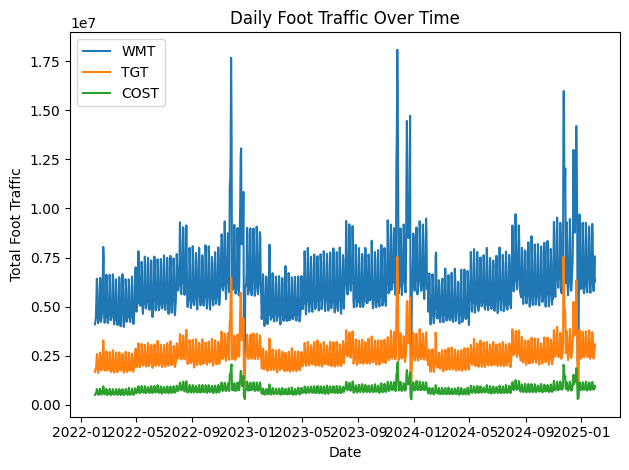

In [10]:
# plotted average daily foot traffic over time for a sample of tickers
# to visually identify seasonality and trends before modeling
sample_tickers = ['WMT', 'TGT', 'COST']

fig, ax = plt.subplots()

for ticker in sample_tickers:
    # filter to one ticker, group by date, sum across all states
    ticker_data = ft[ft['ticker'] == ticker].groupby('date')['foot_traffic'].sum()
    ax.plot(ticker_data.index, ticker_data.values, label=ticker)

ax.set_title('Daily Foot Traffic Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Foot Traffic')
ax.legend()
plt.tight_layout()
plt.show()

## Handling State-Level Granularity

Each ticker is tracked across 10 states that reflect its actual geographic footprint. These state sets differ by company — for example, ACI (Albertsons) is concentrated in western states like CA, CO, and ID, while DG (Dollar General) skews toward southern rural states like AL, MS, and TN.

To handle this state-level granularity, we summed daily foot traffic across all states within each ticker-quarter combination. This collapses the geographic dimension into a single quarterly total per company.

This approach was chosen because:
- We are interested in each company's overall traffic signal, not individual state performance
- Since the 10 states differ per ticker, cross-state comparisons would be misleading
- Summing within a ticker preserves the total signal cleanly

An alternative approach would be to weight states by store count or population, but without store-level data that would introduce assumptions we cannot validate. A state-level heatmap is included in the web application to allow further geographic exploration.

In [11]:
# created a function to assign each date to its corresponding fiscal quarter
# Q1=Feb-Apr, Q2=May-Jul, Q3=Aug-Oct, Q4=Nov-Jan
def assign_fiscal_quarter(date):
    month = date.month
    year = date.year
    
    if month in [2, 3, 4]:
        return f'{year}-Q1'
    elif month in [5, 6, 7]:
        return f'{year}-Q2'
    elif month in [8, 9, 10]:
        return f'{year}-Q3'
    else:  # November, December belong to current year Q4, January belongs to prior year Q4
        if month == 1:
            return f'{year - 1}-Q4'
        else:
            return f'{year}-Q4'

# applied the function to every row in the foot traffic dataset
ft['fiscal_quarter'] = ft['date'].apply(assign_fiscal_quarter)

print(ft[['date', 'fiscal_quarter']].head(10))

        date fiscal_quarter
0 2022-02-01        2022-Q1
1 2022-02-01        2022-Q1
2 2022-02-01        2022-Q1
3 2022-02-01        2022-Q1
4 2022-02-01        2022-Q1
5 2022-02-01        2022-Q1
6 2022-02-01        2022-Q1
7 2022-02-01        2022-Q1
8 2022-02-01        2022-Q1
9 2022-02-01        2022-Q1


In [12]:
# confirmed the fiscal quarter assignment covers all 12 expected quarters
print("Unique fiscal quarters in foot traffic:")
print(sorted(ft['fiscal_quarter'].unique()))

Unique fiscal quarters in foot traffic:
['2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']


In [13]:
# aggregated daily foot traffic into quarterly metrics per ticker
# total_traffic = sum of all daily visits across all states in that quarter
# avg_daily_traffic = average daily visits, smooths out quarter length differences
# peak_traffic = single highest day in the quarter, captures holiday spikes
quarterly_traffic = ft.groupby(['ticker', 'fiscal_quarter']).agg(
    total_traffic=('foot_traffic', 'sum'),
    avg_daily_traffic=('foot_traffic', 'mean'),
    peak_traffic=('foot_traffic', 'max')
).reset_index()

print(quarterly_traffic.shape)
print(quarterly_traffic.head(10))

(240, 5)
  ticker fiscal_quarter  total_traffic  avg_daily_traffic  peak_traffic
0    ACI        2022-Q1      202268326      227267.782022        487850
1    ACI        2022-Q2      233439648      253738.747826        618092
2    ACI        2022-Q3      249841425      271566.766304        604246
3    ACI        2022-Q4      297254969      323103.227174       1290565
4    ACI        2023-Q1      203940745      229146.904494        541736
5    ACI        2023-Q2      239804278      260656.823913        605120
6    ACI        2023-Q3      250436836      272213.952174        608126
7    ACI        2023-Q4      304904039      331417.433696       1124286
8    ACI        2024-Q1      205154016      227948.906667        527572
9    ACI        2024-Q2      241830589      262859.335870        624630


In [14]:
# calculated quarter-over-quarter traffic growth rate per ticker
# sorted by ticker and quarter to ensure growth is calculated in the right order
quarterly_traffic = quarterly_traffic.sort_values(['ticker', 'fiscal_quarter'])

# pct_change() calculates the percentage change from the previous row
# groupby ensures we don't calculate growth across different tickers
quarterly_traffic['traffic_qoq_growth'] = (
    quarterly_traffic.groupby('ticker')['total_traffic']
    .pct_change() * 100
)

print(quarterly_traffic.head(12))

   ticker fiscal_quarter  total_traffic  avg_daily_traffic  peak_traffic  \
0     ACI        2022-Q1      202268326      227267.782022        487850   
1     ACI        2022-Q2      233439648      253738.747826        618092   
2     ACI        2022-Q3      249841425      271566.766304        604246   
3     ACI        2022-Q4      297254969      323103.227174       1290565   
4     ACI        2023-Q1      203940745      229146.904494        541736   
5     ACI        2023-Q2      239804278      260656.823913        605120   
6     ACI        2023-Q3      250436836      272213.952174        608126   
7     ACI        2023-Q4      304904039      331417.433696       1124286   
8     ACI        2024-Q1      205154016      227948.906667        527572   
9     ACI        2024-Q2      241830589      262859.335870        624630   
10    ACI        2024-Q3      251331804      273186.743478        634264   
11    ACI        2024-Q4      314089023      341401.111957       1153638   

    traffic

In [15]:
# merged quarterly traffic features with reported actuals
# used an inner join to keep only rows that exist in both datasets
# 'left_on' and 'right_on' because the quarter column has different names in each dataframe
model_df = quarterly_traffic.merge(
    ra,
    left_on=['ticker', 'fiscal_quarter'],
    right_on=['ticker', 'quarter'],
    how='inner'
)

print(model_df.shape)
print(model_df.head())

(240, 10)
  ticker fiscal_quarter  total_traffic  avg_daily_traffic  peak_traffic  \
0    ACI        2022-Q1      202268326      227267.782022        487850   
1    ACI        2022-Q2      233439648      253738.747826        618092   
2    ACI        2022-Q3      249841425      271566.766304        604246   
3    ACI        2022-Q4      297254969      323103.227174       1290565   
4    ACI        2023-Q1      203940745      229146.904494        541736   

   traffic_qoq_growth  quarter  reported_sss_pct  reported_revenue_mm  \
0                 NaN  2022-Q1              2.35              16400.6   
1           15.410877  2022-Q2             -1.19              17945.4   
2            7.026132  2022-Q3              1.72              17987.1   
3           18.977455  2022-Q4              0.19              20991.0   
4          -31.391981  2023-Q1              0.73              15592.7   

  earnings_date  
0    2022-05-16  
1    2022-08-15  
2    2022-11-14  
3    2023-02-24  
4    2023-

In [16]:
# dropped the duplicate quarter column since fiscal_quarter contains the same information
model_df = model_df.drop(columns=['quarter'])

print(model_df.columns.tolist())

['ticker', 'fiscal_quarter', 'total_traffic', 'avg_daily_traffic', 'peak_traffic', 'traffic_qoq_growth', 'reported_sss_pct', 'reported_revenue_mm', 'earnings_date']


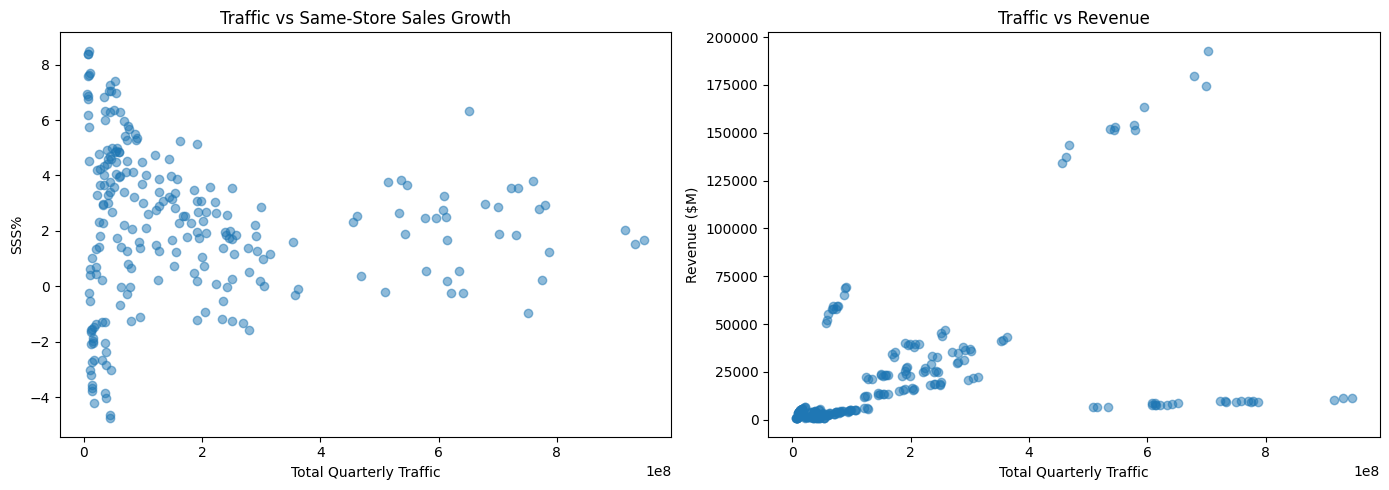

In [17]:
# plotted traffic vs SSS% to visually check if a relationship exists
# if the dots form an upward trend, traffic is likely a good predictor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# total traffic vs SSS%
axes[0].scatter(model_df['total_traffic'], model_df['reported_sss_pct'], alpha=0.5)
axes[0].set_xlabel('Total Quarterly Traffic')
axes[0].set_ylabel('SSS%')
axes[0].set_title('Traffic vs Same-Store Sales Growth')

# total traffic vs Revenue
axes[1].scatter(model_df['total_traffic'], model_df['reported_revenue_mm'], alpha=0.5)
axes[1].set_xlabel('Total Quarterly Traffic')
axes[1].set_ylabel('Revenue ($M)')
axes[1].set_title('Traffic vs Revenue')

plt.tight_layout()
plt.show()

In [18]:
# normalized traffic within each ticker to remove company size bias
model_df['traffic_normalized'] = model_df.groupby('ticker')['total_traffic'].transform(
    lambda x: (x - x.mean()) / x.std()
)

print(model_df[['ticker', 'fiscal_quarter', 'total_traffic', 'traffic_normalized']].head(12))

   ticker fiscal_quarter  total_traffic  traffic_normalized
0     ACI        2022-Q1      202268326           -1.231018
1     ACI        2022-Q2      233439648           -0.419011
2     ACI        2022-Q3      249841425            0.008252
3     ACI        2022-Q4      297254969            1.243365
4     ACI        2023-Q1      203940745           -1.187451
5     ACI        2023-Q2      239804278           -0.253214
6     ACI        2023-Q3      250436836            0.023762
7     ACI        2023-Q4      304904039            1.442622
8     ACI        2024-Q1      205154016           -1.155846
9     ACI        2024-Q2      241830589           -0.200429
10    ACI        2024-Q3      251331804            0.047076
11    ACI        2024-Q4      314089023            1.681889


In [19]:
# Model

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# used normalized traffic and qoq growth as features to predict each KPI
# dropped NaN rows from qoq growth column since first quarter has no prior quarter
model_data = model_df.dropna(subset=['traffic_qoq_growth'])

features = ['traffic_normalized', 'traffic_qoq_growth']
X = model_data[features]

# train a separate model for each KPI
y_sss = model_data['reported_sss_pct']
y_rev = model_data['reported_revenue_mm']

model_sss = LinearRegression().fit(X, y_sss)
model_rev = LinearRegression().fit(X, y_rev)

print("SSS% model coefficients:", model_sss.coef_)
print("Revenue model coefficients:", model_rev.coef_)

SSS% model coefficients: [-0.10621218  0.00337722]
Revenue model coefficients: [2.09870456e+03 4.77072928e-01]


In [21]:
model_data = model_data.copy()
model_data['pred_sss'] = model_sss.predict(X)
model_data['pred_revenue'] = model_rev.predict(X)

print("SSS% MAE:", round(mean_absolute_error(y_sss, model_data['pred_sss']), 3))
print("Revenue MAE:", round(mean_absolute_error(y_rev, model_data['pred_revenue']), 3))

print("SSS% R2:", round(r2_score(y_sss, model_data['pred_sss']), 3))
print("Revenue R2:", round(r2_score(y_rev, model_data['pred_revenue']), 3))

SSS% MAE: 2.226
Revenue MAE: 21814.397
SSS% R2: 0.001
Revenue R2: 0.003


In [22]:
# previewing state level traffic for a single ticker and quarter
# to understand the data before building the heatmap
sample = ft[(ft['ticker'] == 'WMT') & (ft['fiscal_quarter'] == '2024-Q4')]
print(sample.groupby('state')['foot_traffic'].sum().sort_values(ascending=False))

state
TX    109680940
CA    100340232
FL     92568948
OH     82718508
IL     75562083
GA     65964740
NC     57152834
PA     47853615
NY     40103895
MI     30822482
Name: foot_traffic, dtype: int64


## Initial Model — Cross-Ticker Baseline

We first trained a linear regression model across all 20 tickers using normalized traffic and quarter-over-quarter growth as features.

**Results:**
- SSS% MAE: 2.226 | R2: 0.001
- Revenue MAE: $21,814M | R2: 0.003

**Observation:** The model performs poorly across the board. R2 values near zero indicate that traffic alone explains almost none of the variation in either KPI when all tickers are pooled together. This is expected — company size differences dominate the signal. Walmart will always have more traffic and more revenue than Abercrombie, but that doesn't mean traffic *changes* predict financial *changes*.

**Next step:** Build per-ticker models to isolate within-company trends, where the relationship between traffic fluctuations and financial performance is more likely to surface.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# built a separate linear regression model for each ticker
# this isolates within-company trends rather than comparing across companies
results = []

for ticker in model_data['ticker'].unique():
    # filter to just this ticker
    ticker_df = model_data[model_data['ticker'] == ticker]
    
    X_ticker = ticker_df[features]
    y_sss_ticker = ticker_df['reported_sss_pct']
    y_rev_ticker = ticker_df['reported_revenue_mm']
    
    # fit models
    sss_model = LinearRegression().fit(X_ticker, y_sss_ticker)
    rev_model = LinearRegression().fit(X_ticker, y_rev_ticker)
    
    # store predictions and errors
    results.append({
        'ticker': ticker,
        'sss_mae': round(mean_absolute_error(y_sss_ticker, sss_model.predict(X_ticker)), 3),
        'sss_r2': round(r2_score(y_sss_ticker, sss_model.predict(X_ticker)), 3),
        'rev_mae': round(mean_absolute_error(y_rev_ticker, rev_model.predict(X_ticker)), 3),
        'rev_r2': round(r2_score(y_rev_ticker, rev_model.predict(X_ticker)), 3),
    })

results_df = pd.DataFrame(results).sort_values('sss_r2', ascending=False)
print(results_df.to_string(index=False))

ticker  sss_mae  sss_r2  rev_mae  rev_r2
   KSS    0.936   0.440   85.806   0.948
   JWN    0.853   0.361   73.695   0.941
   WMT    0.721   0.314 3914.281   0.904
     M    1.093   0.295  145.172   0.917
    DG    0.783   0.268  178.520   0.931
  FIVE    1.275   0.261   24.941   0.894
   TGT    0.926   0.238  926.534   0.814
    HD    0.921   0.232  913.650   0.921
  ULTA    0.858   0.232   62.858   0.877
  COST    0.755   0.221 1349.201   0.919
  BURL    0.661   0.200   70.980   0.873
  ROST    0.687   0.195  132.294   0.874
  DLTR    1.089   0.194  109.625   0.976
   ANF    0.931   0.183   13.654   0.976
   GPS    0.754   0.136   76.587   0.924
   AEO    0.813   0.091   30.441   0.894
   TJX    0.912   0.058  320.649   0.901
   ACI    0.851   0.050  287.417   0.964
   LOW    0.875   0.046  443.421   0.937
    KR    1.052   0.000  794.157   0.918


## Per-Ticker Models — Key Findings

After isolating models by ticker, the signal improved significantly.

**Revenue (rev_r2):**
Foot traffic is a strong predictor of quarterly revenue across nearly all tickers, with most R2 values above 0.87. The best performing tickers were DLTR and ANF at 0.976, meaning foot traffic explained over 97% of their revenue variation.

**SSS% (sss_r2):**
Foot traffic is a weaker predictor of same-store sales growth. The strongest signals were found in KSS (0.440), JWN (0.361), and WMT (0.314). Grocers like KR showed no meaningful relationship (R2 = 0.000), likely because grocery sales are driven more by price and necessity than visit frequency.

**Conclusion:**
Foot traffic data is significantly more useful for forecasting revenue than SSS%. This is likely because revenue scales directly with the number of visitors, while SSS% is influenced by factors foot traffic cannot capture — pricing strategy, promotions, and average transaction value.

In [24]:
# generated predictions for every ticker and stored them for evaluation
all_preds = []

for ticker in model_data['ticker'].unique():
    ticker_df = model_data[model_data['ticker'] == ticker].copy()
    
    X_ticker = ticker_df[features]
    
    sss_model = LinearRegression().fit(X_ticker, ticker_df['reported_sss_pct'])
    rev_model = LinearRegression().fit(X_ticker, ticker_df['reported_revenue_mm'])
    
    ticker_df['pred_sss'] = sss_model.predict(X_ticker)
    ticker_df['pred_revenue'] = rev_model.predict(X_ticker)
    
    all_preds.append(ticker_df)

preds_df = pd.concat(all_preds).reset_index(drop=True)

print(preds_df[['ticker', 'fiscal_quarter', 'reported_sss_pct', 'pred_sss', 'reported_revenue_mm', 'pred_revenue']].head(10))

  ticker fiscal_quarter  reported_sss_pct  pred_sss  reported_revenue_mm  \
0    ACI        2022-Q2             -1.19  0.249907              17945.4   
1    ACI        2022-Q3              1.72  0.228716              17987.1   
2    ACI        2022-Q4              0.19  0.449023              20991.0   
3    ACI        2023-Q1              0.73 -0.193449              15592.7   
4    ACI        2023-Q2              1.87  0.283916              18527.8   
5    ACI        2023-Q3              0.27  0.210146              18791.7   
6    ACI        2023-Q4              0.02  0.491126              22055.6   
7    ACI        2024-Q1             -0.93 -0.200486              16113.3   
8    ACI        2024-Q2             -0.04  0.291631              18489.1   
9    ACI        2024-Q3             -1.24  0.208620              19614.7   

   pred_revenue  
0  18030.739020  
1  18737.500694  
2  21295.275560  
3  15879.496828  
4  18382.193858  
5  18730.618041  
6  21719.907366  
7  15921.779050  
8

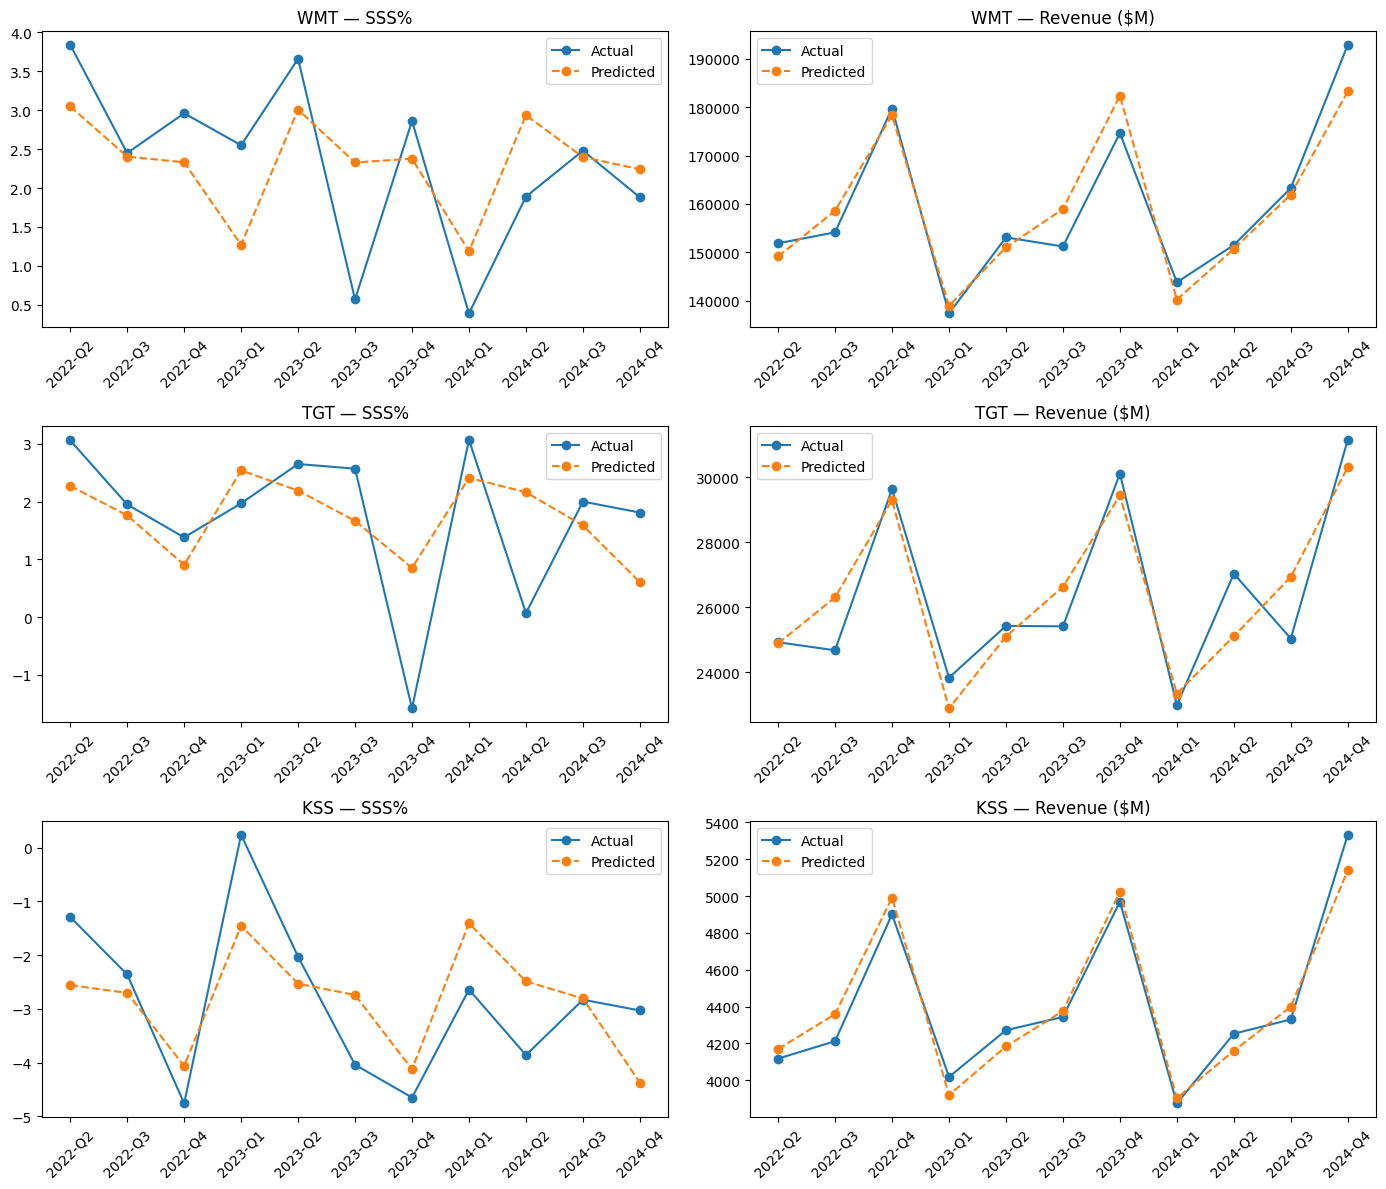

In [25]:
# plotted predicted vs actual for both KPIs for a sample of tickers
sample = ['WMT', 'TGT', 'KSS']

fig, axes = plt.subplots(len(sample), 2, figsize=(14, 12))

for i, ticker in enumerate(sample):
    df_t = preds_df[preds_df['ticker'] == ticker].sort_values('fiscal_quarter')
    
    # SSS%
    axes[i, 0].plot(df_t['fiscal_quarter'], df_t['reported_sss_pct'], label='Actual', marker='o')
    axes[i, 0].plot(df_t['fiscal_quarter'], df_t['pred_sss'], label='Predicted', marker='o', linestyle='--')
    axes[i, 0].set_title(f'{ticker} — SSS%')
    axes[i, 0].tick_params(axis='x', rotation=45)
    axes[i, 0].legend()
    
    # Revenue
    axes[i, 1].plot(df_t['fiscal_quarter'], df_t['reported_revenue_mm'], label='Actual', marker='o')
    axes[i, 1].plot(df_t['fiscal_quarter'], df_t['pred_revenue'], label='Predicted', marker='o', linestyle='--')
    axes[i, 1].set_title(f'{ticker} — Revenue ($M)')
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Per-Ticker Forecast Evaluation — Visual Analysis

Predicted vs actual results were plotted for WMT, TGT, and KSS across 11 quarters.

**Revenue:**
Foot traffic predicts revenue well across all three tickers. The model successfully captures seasonal patterns — Q4 holiday spikes and Q1 post-holiday dips — with predicted values tracking closely to actuals. KSS showed the tightest fit, with predicted and actual lines nearly overlapping throughout the entire period.

**SSS%:**
Results are more mixed. The model captures the general direction of SSS% movement but struggles with sudden sharp changes. TGT's unexpected drop in 2023-Q4 was missed entirely, and KSS predictions consistently overshoot the magnitude of declines. This suggests foot traffic can identify trends but cannot anticipate event-driven shifts in same-store performance.

**Takeaway:**
The model performs consistently better on revenue than SSS% across all tickers and time periods. Seasonal patterns are the strongest signal in the foot traffic data — the model is most reliable in quarters where traffic patterns are predictable and least reliable when external factors cause unexpected swings.

## Portfolio Manager Recommendation

**Question: Is this foot traffic data worth subscribing to?**

**Short answer: Yes, selectively.**

After analyzing daily foot traffic data across 20 retail tickers and 12 fiscal quarters, foot traffic proves to be a strong predictor of quarterly revenue but a weak predictor of same-store sales growth (SSS%).

**Revenue Forecasting:**
Per-ticker linear regression models achieved R2 values above 0.87 for nearly all tickers, meaning foot traffic explained over 87% of quarterly revenue variation. The strongest fits were DLTR and ANF at R2 = 0.976, and ACI at 0.964. This level of accuracy suggests the data could give the fund a meaningful edge in revenue forecasting before earnings are officially reported.

**SSS% Forecasting:**
Results were significantly weaker. The best performing tickers for SSS% were KSS (R2 = 0.440), JWN (R2 = 0.361), and WMT (R2 = 0.314). Grocers like KR showed no meaningful relationship (R2 = 0.000), likely because grocery purchases are driven by necessity and price rather than discretionary visit frequency. SSS% is influenced by pricing strategy, promotions, and consumer sentiment — factors that foot traffic volume alone cannot capture.

**Best Use Cases:**
This data source is most valuable for revenue forecasting in mid-size specialty and department store retailers — particularly KSS, JWN, ANF, and DLTR. These names showed strong and consistent signal across both KPIs. Avoid relying on this data for SSS% forecasting for grocers and value retailers like KR and ACI where the signal is weakest.

**Limitations:**
- The data covers only 10 states per ticker, which may not fully represent each company's national footprint
- The model is trained and tested on the same data, meaning real out-of-sample performance may be weaker
- The model struggles with sudden event-driven changes such as TGT's unexpected SSS% drop in 2023-Q4
- Only 12 quarters of data limits the model's ability to generalize across different economic environments

**Assumptions:**
- Fiscal quarters align as Q1=Feb-Apr, Q2=May-Jul, Q3=Aug-Oct, Q4=Nov-Jan consistently across all tickers
- The 10 states tracked per ticker are representative of each company's broader traffic patterns
- Foot traffic counts are accurate and consistent across the full date range

**Recommendation:**
Subscribe to this data source and use it primarily for revenue forecasting on specialty and department store retailers. Pair it with additional alternative data — consumer sentiment indices, credit card transaction data, or pricing data — to meaningfully improve SSS% predictions. Do not rely on this data source alone for grocer or value retailer analysis.